In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data source: Kaggle (Sentiment Analysis on Movie Reviews)

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/nlp/transformers-language-classification/train.tsv.zip', 'r') as zipFile:
  zipFile.extractall('./')


In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/nlp/transformers-language-classification/test.tsv.zip', 'r') as zipFile:
  zipFile.extractall('./')

In [ ]:
!pip3 install transformers

In [ ]:
from transformers import AutoTokenizer
from transformers import TFAutoModel

In [ ]:
import pandas as pd


train_df= pd.read_csv('train.tsv', sep='\t')

In [ ]:
train_df.head(5)

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [ ]:
train_df['Sentiment'].value_counts()

2    79582
3    32927
1    27273
4     9206
0     7072
Name: Sentiment, dtype: int64

In [ ]:
train_df.shape

(156060, 4)

In [ ]:
train_df.drop_duplicates(subset='SentenceId', keep='first',inplace= True)

In [ ]:
train_df.head(5)

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
63,64,2,"This quiet , introspective and entertaining in...",4
81,82,3,"Even fans of Ismail Merchant 's work , I suspe...",1
116,117,4,A positively thrilling combination of ethnogra...,3
156,157,5,Aggressive self-glorification and a manipulati...,1


In [ ]:
train_df.shape

(8529, 4)

In [ ]:
sequence_length= train_df['Phrase'].apply(lambda x: len(x.split()))

In [ ]:
print(max(sequence_length))

52


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# %matplotlib inline

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


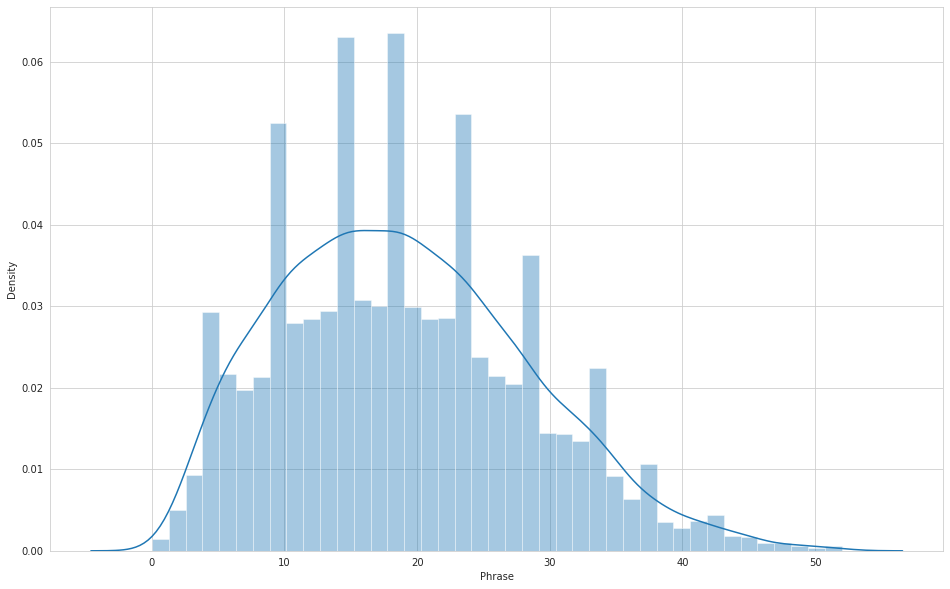

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(16,10))
sns.distplot(sequence_length)

In [ ]:
SEQ_LEN=52

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')


Downloading:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/208k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/426k [00:00<?, ?B/s]

In [ ]:
tokens = tokenizer.encode_plus('hello world', max_length= SEQ_LEN,
                               truncation=True, padding='max_length',
                               add_special_tokens= True, return_token_type_ids=False,
                               return_attention_mask=True, return_tensors='tf')

In [ ]:
tokens

{'input_ids': <tf.Tensor: shape=(1, 52), dtype=int32, numpy=
array([[  101, 19082,  1362,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(1, 52), dtype=int32, numpy=
array([[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)>}

In [ ]:
import numpy as np

In [ ]:
Xids= np.zeros((len(train_df), SEQ_LEN))
Xmask= np.zeros((len(train_df), SEQ_LEN))

In [ ]:
for i, sequence in enumerate(train_df['Phrase']):
  tokens = tokenizer.encode_plus(sequence, max_length= SEQ_LEN,
                               truncation=True, padding='max_length',
                               add_special_tokens= True, return_token_type_ids=False,
                               return_attention_mask=True, return_tensors='tf')
  Xids[i,:] = tokens['input_ids']
  Xmask[i,:] = tokens['attention_mask']



In [ ]:
Xids

array([[ 101.,  138., 1326., ...,    0.,    0.,    0.],
       [ 101., 1188., 3589., ...,    0.,    0.,    0.],
       [ 101., 2431., 3899., ...,    0.,    0.,    0.],
       ...,
       [ 101.,  118.,  149., ...,    0.,    0.,    0.],
       [ 101., 1109., 2523., ...,    0.,    0.,    0.],
       [ 101., 1109., 1273., ...,    0.,    0.,    0.]])

In [ ]:
Xmask

array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]])

In [ ]:
arr= train_df['Sentiment'].values

In [ ]:
arr.size

8529

In [ ]:
labels = np.zeros((arr.size, arr.max()+1))
labels.shape

(8529, 5)

In [ ]:
labels[np.arange(arr.size),arr]=1

In [ ]:
labels

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [ ]:
with open('Xids.npy','wb') as f:
  np.save(f,Xids)
with open('Xmask.npy','wb') as f:
  np.save(f,Xmask)
with open('labels.npy','wb') as f:
  np.save(f,labels)

In [ ]:
import tensorflow as tf
tf.config.experimental.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
dataset= tf.data.Dataset.from_tensor_slices((Xids,Xmask,labels))

In [ ]:
for i in dataset.take(1):
  print(i)

(<tf.Tensor: shape=(52,), dtype=float64, numpy=
array([  101.,   138.,  1326.,  1104., 13936., 25265., 16913., 15107.,
        1103.,  8050.,  2553.,  1115.,  1184.,  1110.,  1363.,  1111.,
        1103., 20398.,  1110.,  1145.,  1363.,  1111.,  1103.,   176.,
        9900.,   117.,  1199.,  1104.,  1134.,  5411.,  1821., 14225.,
        1133.,  3839.,  1104.,  1134.,  7919.,  1106.,  1277.,  1104.,
         170.,  1642.,   119.,   102.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.])>, <tf.Tensor: shape=(52,), dtype=float64, numpy=
array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0.])>, <tf.Tensor: shape=(5,), dtype=float64, numpy=array([0., 1., 0., 0., 0.])>)


In [ ]:
dataset

<TensorSliceDataset shapes: ((52,), (52,), (5,)), types: (tf.float64, tf.float64, tf.float64)>

In [ ]:
def map_function(input_ids, masks, label):
  return({'input_ids':input_ids,'attention_mask':masks},label)

In [ ]:
dataset=dataset.map(map_function)

In [ ]:
for i in dataset.take(1):
  print(i)

({'input_ids': <tf.Tensor: shape=(52,), dtype=float64, numpy=
array([  101.,   138.,  1326.,  1104., 13936., 25265., 16913., 15107.,
        1103.,  8050.,  2553.,  1115.,  1184.,  1110.,  1363.,  1111.,
        1103., 20398.,  1110.,  1145.,  1363.,  1111.,  1103.,   176.,
        9900.,   117.,  1199.,  1104.,  1134.,  5411.,  1821., 14225.,
        1133.,  3839.,  1104.,  1134.,  7919.,  1106.,  1277.,  1104.,
         170.,  1642.,   119.,   102.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.])>, 'attention_mask': <tf.Tensor: shape=(52,), dtype=float64, numpy=
array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0.])>}, <tf.Tensor: shape=(5,), dtype=float64, numpy=array([0., 1., 0., 0., 0.])>)


In [ ]:
dataset= dataset.shuffle(10000).batch(32)

In [ ]:
LEN_DF= len(list(dataset))

In [ ]:
split=.9

In [ ]:
train=dataset.take(round(split*LEN_DF))

In [ ]:
test=dataset.skip(round(split*LEN_DF))

In [ ]:
len(list(train))

240

In [ ]:
bert= TFAutoModel.from_pretrained('bert-base-cased')

Downloading:   0%|          | 0.00/502M [00:00<?, ?B/s]

Some layers from the model checkpoint at bert-base-cased were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-cased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


In [ ]:
input_ids= tf.keras.layers.Input(shape=(SEQ_LEN), name='input_ids',dtype='int32')
mask = tf.keras.layers.Input(shape=(SEQ_LEN), name='attention_mask',dtype='int32')

embeddings= bert(input_ids, attention_mask=mask)[0]

X= tf.keras.layers.GlobalMaxPool1D()(embeddings)
X= tf.keras.layers.BatchNormalization()(X)
X= tf.keras.layers.Dense(128, activation='relu')(X)
X= tf.keras.layers.Dropout(0.1)(X)
X= tf.keras.layers.Dense(32, activation='relu')(X)
y= tf.keras.layers.Dense(5, activation='softmax', name='outputs')(X)

model= tf.keras.Model(inputs=[input_ids,mask], outputs=y)

model.layers[2].trainable= False


In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 52)]         0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 52)]         0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  108310272   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 52,                                            

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss= tf.keras.losses.CategoricalCrossentropy()
acc= tf.keras.metrics.CategoricalAccuracy('accuracy')

model.compile(optimizer=optimizer, loss= loss, metrics=[acc])

In [ ]:
history= model.fit(train, validation_data=test, epochs=100)

Epoch 1/100
240/240 [==============================] - 79s 263ms/step - loss: 1.4710 - accuracy: 0.3585 - val_loss: 1.2864 - val_accuracy: 0.4523
Epoch 2/100
240/240 [==============================] - 60s 249ms/step - loss: 1.3538 - accuracy: 0.3979 - val_loss: 1.2538 - val_accuracy: 0.4299
Epoch 3/100
240/240 [==============================] - 60s 248ms/step - loss: 1.3332 - accuracy: 0.4112 - val_loss: 1.2457 - val_accuracy: 0.4335
Epoch 4/100
240/240 [==============================] - 60s 248ms/step - loss: 1.3075 - accuracy: 0.4201 - val_loss: 1.2644 - val_accuracy: 0.4229
Epoch 5/100
240/240 [==============================] - 60s 249ms/step - loss: 1.3126 - accuracy: 0.4208 - val_loss: 1.1873 - val_accuracy: 0.4688
Epoch 6/100
240/240 [==============================] - 60s 247ms/step - loss: 1.2935 - accuracy: 0.4313 - val_loss: 1.1629 - val_accuracy: 0.4994
Epoch 7/100
240/240 [==============================] - 60s 248ms/step - loss: 1.2880 - accuracy: 0.4391 - val_loss: 1.1639 -